In [1]:
# Install required packages
import sys
!{sys.executable} -m pip install scikit-optimize scikit-learn matplotlib seaborn pandas numpy

In [2]:
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from collections import Counter
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, classification_report
)
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

warnings.filterwarnings('ignore')
print("All packages imported")

All packages imported


In [3]:
# File paths 
pca_file = "C:\\Users\\12402\\Desktop\\ml final\\rnaseqclassify-main\\heart_aorta_qc_normalized_pca.csv" 
cluster_file = "C:\\Users\\12402\\Desktop\\ml final\\rnaseqclassify-main\\cell_clusters.csv" 
test_set = 0.30   
seed = 42

# Number of GM optimization runs 
n_calls_SVM = 30
n_calls_RF = 30
n_calls_DT = 30

# Creates output directory
import os
outputs = "results"
os.makedirs(outputs, exist_ok=True)
print(f"Outputs will be saved to: {os.path.abspath(outputs)}/")

Outputs will be saved to: c:\Users\12402\Desktop\ml final\rnaseqclassify-main\gaussian_process\results/


In [4]:
def load_data(pca_filepath, clusters_filepath, test_size=0.3, random_state=42):
    # Loads PCA and cluster files, merges by cell barcode, and returns 70/30 train/test splits.

    pca_df = pd.read_csv(pca_filepath,      index_col=0)
    clusters_df = pd.read_csv(clusters_filepath, index_col=0)

    merged = pca_df.join(clusters_df, how='inner')
    if merged.empty:
        raise ValueError("No shared barcodes between files")

    label_col = clusters_df.columns[0]
    X = merged.drop(columns=[label_col]).values.astype(np.float32)
    y = merged[label_col].values.astype(int)

    # drop rows with any null features
    valid_mask = ~np.isnan(X).any(axis=1)
    X, y = X[valid_mask], y[valid_mask]

    print(f"Cells loaded: {X.shape[0]}")
    print(f"PCA features: {X.shape[1]}")
    print(f"Clusters: {sorted(np.unique(y).tolist())}")

    label_names = sorted(np.unique(y).tolist())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    
    print(f"Train count: {X_train.shape[0]}")
    print(f"Test count: {X_test.shape[0]}")
    return X_train, X_test, y_train, y_test, label_names

In [5]:
X_train, X_test, y_train, y_test, LABEL_NAMES = load_data(
    pca_file, cluster_file,
    test_size=test_set,
    random_state=seed,
)

Cells loaded: 654
PCA features: 23433
Clusters: [0, 1, 2, 3, 4, 5, 6]
Train count: 457
Test count: 197


In [6]:
# Random Forest from Allison

class Node:
    def __init__(self, prediction=None, feature_index=None, threshold=None,
                left=None, right=None, is_leaf=False):
        self.prediction = prediction
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.is_leaf = is_leaf


def random_forest(X, y, n_trees, max_depth, max_features, min_samples_split):
    trees      = []
    n_features = len(X[0])
    if max_features is None:
        max_features = max(1, int(math.sqrt(n_features)))
    for _ in range(n_trees):
        sample_X, sample_y = bootstrap_sample(X, y)
        tree = make_decision_tree(sample_X, sample_y, max_depth, 0,
                                min_samples_split, max_features)
        trees.append(tree)
    return trees


def bootstrap_sample(X, y):
    n = len(X)
    sampled_X, sampled_y = [], []
    for _ in range(n):
        idx = random.randrange(n)
        sampled_X.append(X[idx])
        sampled_y.append(y[idx])
    return sampled_X, sampled_y


def make_decision_tree(X, y, max_depth, depth, min_samples_split, max_features):
    counts = Counter(y)
    node_prediction = counts.most_common(1)[0][0]
    if len(set(y)) == 1:
        return Node(prediction=y[0], is_leaf=True)
    if depth >= max_depth:
        return Node(prediction=node_prediction, is_leaf=True)
    if len(y) < min_samples_split:
        return Node(prediction=node_prediction, is_leaf=True)
    best_split = find_best_split(max_features, X, y)
    if best_split is None:
        return Node(prediction=node_prediction, is_leaf=True)
    feature_index, threshold, left_indices, right_indices = best_split
    left_X  = [X[i] for i in left_indices];  left_y  = [y[i] for i in left_indices]
    right_X = [X[i] for i in right_indices]; right_y = [y[i] for i in right_indices]
    left_child  = make_decision_tree(left_X,  left_y,  max_depth, depth+1, min_samples_split, max_features)
    right_child = make_decision_tree(right_X, right_y, max_depth, depth+1, min_samples_split, max_features)
    return Node(prediction=node_prediction, feature_index=feature_index,
                threshold=threshold, left=left_child, right=right_child, is_leaf=False)


def find_best_split(max_features, X, y):
    n_samples = len(X)
    n_features = len(X[0])
    best_gini = gini_impurity(y)
    best_split = None
    feature_indices = list(range(n_features))
    random.shuffle(feature_indices)
    feature_indices = feature_indices[:max_features]
    for feature_index in feature_indices:
        feature_values = [X[i][feature_index] for i in range(n_samples)]
        unique_values  = sorted(set(feature_values))
        if len(unique_values) < 2:
            continue
        for j in range(len(unique_values) - 1):
            threshold     = (unique_values[j] + unique_values[j+1]) / 2.0
            left_indices  = [i for i in range(n_samples) if X[i][feature_index] <= threshold]
            right_indices = [i for i in range(n_samples) if X[i][feature_index] >  threshold]
            if not left_indices or not right_indices:
                continue
            left_y  = [y[i] for i in left_indices]
            right_y = [y[i] for i in right_indices]
            weighted_gini = ((len(left_y)  / n_samples) * gini_impurity(left_y) +
                            (len(right_y) / n_samples) * gini_impurity(right_y))
            if weighted_gini < best_gini:
                best_gini  = weighted_gini
                best_split = (feature_index, threshold, left_indices, right_indices)
    return best_split


def gini_impurity(y):
    if len(y) == 0:
        return 0.0
    counts = Counter(y)
    n = len(y)
    return 1.0 - sum((c / n) ** 2 for c in counts.values())


def predict_tree(tree, x):
    current = tree
    while not current.is_leaf:
        current = current.left if x[current.feature_index] <= current.threshold else current.right
    return current.prediction


def predict_forest(trees, X):
    predictions = []
    for x in X:
        votes = [predict_tree(tree, x) for tree in trees]
        final_pred = Counter(votes).most_common(1)[0][0]
        predictions.append(final_pred)
    return predictions


def rf_accuracy_score(y_true, y_pred):
    return sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)

print("Random Forest loaded")

Random Forest loaded


In [7]:
# Decision Tree from Alfred

import numpy as np
from collections import Counter
from multiprocessing import Pool, cpu_count

#The following decision tree implementation allows for splitting based on entropy or gini index

class DTNode:
    """Represents a node in the decision tree."""    
    def __init__(self, feature=None, threshold=None, left=None, right=None, cellType=None, numSamples=None, impurity=None):
        self.feature = feature          #Index of feature that is being split with
        self.threshold = threshold      #Threshold value for split
        self.left = left                #Left subtree
        self.right = right              #Right subtree
        self.cellType =  cellType       #(Leaves only): Cell type prediction  
        self.numSamples = numSamples    #Number of samples at this node
        self.impurity = impurity        #Purity measure based on the feature being split on
    
    def isLeaf(self):
        """Check if node is a leaf."""
        return self.cellType is not None #Only leaves have cellType label

class DecisionTree:
    """Decision Tree for classification and regression."""
    def __init__(self, purityMeasure=None, maxDepth = None, minSamplesSplit = None, minSamplesLeaf=None, numJobs=-1):
        self.purityMeasure = purityMeasure                      #Purity measure (gini or entropy) to compute infogain with
        self.maxDepth = maxDepth                                #Max depth tree can grow to (None = unlimited)
        self.minSamplesSplit = minSamplesSplit                  #Minimum samples required to split a node
        self.minSamplesLeaf = minSamplesLeaf                    #Minimum samples required at a leaf node
        self.numJobs = numJobs if numJobs > 0 else cpu_count()  #Number of cpus to use
        self.tree = None
        self.numFeatures = None
        self.classes = None


    def _growTree(self, X, y, depth=0):
        """Recursively grow the decision tree"""

        numSamples = X.shape[0]
        numClasses = len(np.unique(y))

        #Stopping criteria
        if (self.maxDepth is not None and depth >= self.maxDepth) or numSamples < self.minSamplesSplit or numClasses == 1:
            return self._createLeaf(y)
        
        #Try all splits
        bestSplit = self._findBestSplit(X, y)
        
        if bestSplit is None:
            return self._createLeaf(y)
        
        feature, threshold, leftIndex, rightIndex = bestSplit
        
        # Recursively build left and right subtrees
        leftSubtree = self._growTree(X[leftIndex], y[leftIndex], depth + 1)
        rightSubtree = self._growTree(X[rightIndex], y[rightIndex], depth + 1)
        
        # Calculate impurity
        impurity = self._impurity(y)
        
        return DTNode(
            feature=feature,
            threshold=threshold,
            left=leftSubtree,
            right=rightSubtree,
            numSamples=numSamples,
            impurity=impurity
        )
    

    def _findBestSplit(self, X, y):
        """Find the best feature and threshold to split a node"""
        numSamples, numFeatures = X.shape
        bestInfoGain = -np.inf
        bestSplit = None

        if self.numJobs > 1:
            results = []
            with Pool(self.numJobs) as pool:
                for feature in range(numFeatures):
                    result = pool.apply_async(self._evaluateFeature,(feature, X, y, self.minSamplesLeaf))
                    results.append(result)

                splits = [result.get() for result in results]
        
        else:
            splits = [self._evaluateFeature(feature, X, y, self.minSamplesLeaf) for feature in range(numFeatures)]

        
        for feature, threshold, leftIndex, rightIndex, infoGain in splits:
            if infoGain > bestInfoGain:
                bestInfoGain = infoGain
                bestSplit = (feature, threshold, leftIndex, rightIndex)

        return bestSplit


    def _evaluateFeature(self, feature, X, y, minSamplesLeaf):
        """Evaluate a single feature for splitting."""

        #Get unique feature values
        uniqueVals = np.unique(X[:, feature])

        if len(uniqueVals) == 1:
            return (feature, None, None, None, -np.inf)
    
        #Thresholds to test = Midpoint for all consecutive unique feature values
        thresholds = (uniqueVals[:-1] + uniqueVals[1:])/2

        #Initialize variables to track best threshold
        bestInfoGain = -np.inf
        bestSplit = (feature, None, None, None, -np.inf)

        #Test all threhsholds
        for threshold in thresholds:
            leftIndex = X[:, feature] <= threshold
            rightIndex = ~leftIndex

            #Check if children have >minSample
            numLeft = np.sum(leftIndex)
            numRight = np.sum(rightIndex)

            if numLeft < minSamplesLeaf or numRight < minSamplesLeaf:
                continue

            #Compute infoGain for split    
            infoGain = self._infoGain(y, y[leftIndex], y[rightIndex])

            if infoGain > bestInfoGain:
                bestInfoGain = infoGain
                bestSplit = (feature, threshold, leftIndex, rightIndex, infoGain)

        return bestSplit

    def _impurity(self, y):
        """Compute impurity based on criterion."""
        if self.purityMeasure == "entropy":
            return entropy(y)
        elif self.purityMeasure == "gini":
            return gini(y)
        

    def _infoGain(self, node, leftChild, rightChild):
        """Compute the information gain resulting from a feature split for any purity measure"""

        nodeLength = len(node)
        leftLength = len(leftChild)
        rightLength = len(rightChild)

        #If either left or right child has no samples -> Splitting on this feature yields no info gain
        if leftLength == 0 or rightLength == 0:
            return 0.0
    
        nodeImpurity = self._impurity(node)
        
        leftImpurity = self._impurity(leftChild)
        rightImpurity = self._impurity(rightChild)

        #Weighted average of children's impurities
        childImpurity = (leftLength/nodeLength) * leftImpurity + (rightLength/nodeLength) * rightImpurity

        #Information Gain = (Node's Impurity) - (Children's Weighted Average Impurity)
        return nodeImpurity - childImpurity


    def _createLeaf(self, y):
        """Create a leaf node."""

        #Pick most common class via majority vote
        value = Counter(y).most_common(1)[0][0]
        return DTNode(cellType=value, numSamples=len(y), impurity=0)
    

    def _traverseTree(self, x, node):
        """Traverse tree to find prediction for sample x."""

        #Base case
        if node.isLeaf():
            return node.cellType
        
        #Recusively traverse tree
        if x[node.feature] <= node.threshold:
            return self._traverseTree(x, node.left)
        else:
            return self._traverseTree(x, node.right)
    

    #Methods
    def fit(self, X, y):
        """Build decision tree classifier"""
        X = np.array(X)
        y = np.array(y)
        
        self.numFeatures = X.shape[1]
        self.classes = np.unique(y)
        
        #Grow tree
        self.tree = self._growTree(X, y)
        return self

    def predict(self, X):
        """Predict class/value for all samples in data"""
        X = np.array(X)
        return np.array([self._traverseTree(x, self.tree) for x in X])

    def score(self, X, y):
        """Calculate accuracy of predicitions."""
        yPred = self.predict(X)
        return np.mean(yPred == y)


def entropy(labels):
    """Calculate conditional entropy"""
    unique, labelCounts = np.unique(labels, return_counts=True)
    labelProbs = labelCounts/len(labels)

    #Entropy = -Summation of labelProbs*log_2(labelProbs)
    return -np.sum(labelProbs * np.log2(labelProbs + 1e-10)) #Prevent underflow


def gini(labels):
    """Calculate Gini impurity"""
    unique, counts = np.unique(labels, return_counts=True)
    labelProbs = counts/len(labels)

    #Gini = 1 - Summation of labelProbs**2
    return 1.0 - np.sum(labelProbs**2)


def trainAndTestTree(XTrain, XTest, yTrain, yTest, purityMeasure='entropy', 
                        maxDepth=10, minSamplesSplit=5, minSamplesLeaf=2, numJobs=-1,
                        outputPath='trainedTree.pkl'):
    """Train a decision tree classifier and save it to disk."""
    
    print("Training Decision Tree...")
    #Create tree with paramters
    tree = DecisionTree(
        purityMeasure=purityMeasure,
        maxDepth=maxDepth,
        minSamplesSplit=minSamplesSplit,
        minSamplesLeaf=minSamplesLeaf,
        numJobs=numJobs
    )
    
    #Train tree
    tree.fit(XTrain, yTrain)
    
    #Evaluate tree accuracy using training and testing data
    trainAccuracy = tree.score(XTrain, yTrain)
    print(f"Training Accuracy: {trainAccuracy}")
    
    testAccuracy = tree.score(XTest, yTest)
    print(f"Testing Accuracy: {testAccuracy}")

print("Decision Tree loaded")


Decision Tree loaded


In [8]:
# SVM parameter search space
SVM_SPACE = [
    Real(1e-2, 1e3, prior='log-uniform', name='C'),
    Real(1e-4, 1e1, prior='log-uniform', name='gamma'),
    Categorical(['rbf', 'linear'], name='kernel'),
]

# GP Bayesian optimization over the SVM hyperparameter space.
def optimize_svm(X_train, y_train, n_calls=10, random_state=42):

    @use_named_args(SVM_SPACE)
    def objective(C, gamma, kernel):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(C=C, gamma=gamma, kernel=kernel, random_state=random_state)),
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=5,
                                 scoring='accuracy', n_jobs=-1)
        return -scores.mean()    

    print(f"Optimizing SVM with GP ({n_calls} calls)")
    result = gp_minimize(
        objective, SVM_SPACE,
        n_calls=n_calls,
        random_state=random_state,
        n_initial_points=5,
        acq_func='EI',
        verbose=False,
    )
    best_params = {
        'C': result.x[0],
        'gamma': result.x[1],
        'kernel': result.x[2],
    }
    print(f"Best CV accuracy: {-result.fun:.4f}")
    print(f"Best params: {best_params}")
    return best_params, result

In [ ]:
svm_best_params, svm_gp_result = optimize_svm(
    X_train, y_train,
    n_calls=n_calls_SVM,
    random_state=seed,
)

Optimizing SVM with GP (30 calls)


In [ ]:
# RF parameter search space 
RF_SPACE = [
    Integer(50, 200, name='n_trees'),
    Integer(3, 20, name='max_depth'),
    Integer(1, 20, name='max_features'),
    Integer(2, 20, name='min_samples_split'),
]

# GP Bayesian optimization over the Random Forest hyperparameter space
def optimize_rf(X_train, y_train, n_calls=10, random_state=42):
   
    rng       = np.random.RandomState(random_state)
    n         = len(X_train)
    fold_size = n // 5
    indices   = rng.permutation(n)

    def manual_cv(n_trees, max_depth, max_features, min_samples_split):
        fold_accs = []
        for k in range(5):
            val_idx   = indices[k * fold_size: (k + 1) * fold_size]
            train_idx = np.concatenate([indices[:k * fold_size],
                                        indices[(k + 1) * fold_size:]])
            Xtr = [X_train[i].tolist() for i in train_idx]
            ytr = [int(y_train[i])     for i in train_idx]
            Xva = [X_train[i].tolist() for i in val_idx]
            yva = [int(y_train[i])     for i in val_idx]
            trees = random_forest(Xtr, ytr, n_trees=n_trees, max_depth=max_depth,
                                  max_features=max_features,
                                  min_samples_split=min_samples_split)
            preds = predict_forest(trees, Xva)
            fold_accs.append(rf_accuracy_score(yva, preds))
        return float(np.mean(fold_accs))

    @use_named_args(RF_SPACE)
    def objective(n_trees, max_depth, max_features, min_samples_split):
        return -manual_cv(int(n_trees), int(max_depth),
                          int(max_features), int(min_samples_split))

    print(f"Optimizing Random Forest with GP ({n_calls} calls)")
    result = gp_minimize(
        objective, RF_SPACE,
        n_calls=n_calls,
        random_state=random_state,
        n_initial_points=5,
        acq_func='EI',
        verbose=False,
    )
    best_params = {
        'n_trees': int(result.x[0]),
        'max_depth': int(result.x[1]),
        'max_features': int(result.x[2]),
        'min_samples_split': int(result.x[3]),
    }
    print(f"Best CV accuracy: {-result.fun:.4f}")
    print(f"Best params: {best_params}")
    return best_params, result

In [ ]:
rf_best_params, rf_gp_result = optimize_rf(
    X_train, y_train,
    n_calls=n_calls_RF,
    random_state=seed,
)

Optimizing Random Forest with GP (30 calls)


In [ ]:
# DT parameter search space
DT_SPACE = [
    Integer(2, 20, name='max_depth'),
    Integer(2, 20, name='min_samples_split'),
    Integer(1, 20, name='min_samples_leaf'),
    Categorical(['gini', 'entropy'], name='purity_measure'),
]

# GP Bayesian optimization over the Decision Tree hyperparameter space.
def optimize_dt(X_train, y_train, n_calls=5, random_state=42):

    rng       = np.random.RandomState(random_state)
    n         = len(X_train)
    fold_size = n // 5
    indices   = rng.permutation(n)

    def manual_cv(max_depth, min_samples_split, min_samples_leaf, purity_measure):
        fold_accs = []
        for k in range(5):
            val_idx   = indices[k * fold_size: (k + 1) * fold_size]
            train_idx = np.concatenate([indices[:k * fold_size],
                                        indices[(k + 1) * fold_size:]])
            Xtr = X_train[train_idx]
            ytr = y_train[train_idx]
            Xva = X_train[val_idx]
            yva = y_train[val_idx]
            clf = DecisionTree(
                purityMeasure=purity_measure,
                maxDepth=max_depth,
                minSamplesSplit=min_samples_split,
                minSamplesLeaf=min_samples_leaf,
            )
            clf.fit(Xtr, ytr)
            preds = clf.predict(Xva)
            fold_accs.append(np.mean(preds == yva))
        return float(np.mean(fold_accs))

    @use_named_args(DT_SPACE)
    def objective(max_depth, min_samples_split, min_samples_leaf, purity_measure):
        return -manual_cv(int(max_depth), int(min_samples_split),
                          int(min_samples_leaf), purity_measure)

    print(f"Optimizing Decision Tree with GP ({n_calls} calls)")
    result = gp_minimize(
        objective, DT_SPACE,
        n_calls=n_calls,
        random_state=random_state,
        n_initial_points=5,
        acq_func='EI',
        verbose=False,
    )
    best_params = {
        'max_depth':         int(result.x[0]),
        'min_samples_split': int(result.x[1]),
        'min_samples_leaf':  int(result.x[2]),
        'purity_measure':    result.x[3],
    }
    print(f"Best CV accuracy: {-result.fun:.4f}")
    print(f"Best params: {best_params}")
    return best_params, result


In [ ]:
dt_best_params, dt_gp_result = optimize_dt(
    X_train, y_train,
    n_calls=n_calls_DT,
    random_state=seed,
)

Optimizing Decision Tree with GP (5 calls)
Best CV accuracy: 0.9407
Best params: {'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 10, 'purity_measure': 'gini'}


In [ ]:
# Retrain each model on the full training set using the hyperparameters found by GP

# SVM 
def train_svm(X_train, y_train, params):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**params, probability=True, random_state=seed)),
    ])
    pipe.fit(X_train, y_train)
    return pipe

# Random Forest 
def train_rf(X_train, y_train, params):
    Xtr = [row.tolist() for row in X_train]
    ytr = [int(v)        for v   in y_train]
    return random_forest(Xtr, ytr, **params)

# Decision Tree 
def train_dt(X_train, y_train, params):
    clf = DecisionTree(
        purityMeasure=params['purity_measure'],
        maxDepth=params['max_depth'],
        minSamplesSplit=params['min_samples_split'],
        minSamplesLeaf=params['min_samples_leaf'],
    )
    clf.fit(X_train, y_train)
    return clf

print("Training SVM")
svm_model = train_svm(X_train, y_train, svm_best_params)
print("Training Random Forest")
rf_model  = train_rf( X_train, y_train, rf_best_params)
print("Training Decision Tree")
dt_model  = train_dt( X_train, y_train, dt_best_params)
print("All models trained.")

Training SVM
Training Random Forest
Training Decision Tree
All models trained.


In [ ]:
# Predict 
svm_preds = svm_model.predict(X_test)
rf_preds  = np.array(predict_forest(rf_model, [row.tolist() for row in X_test]))
dt_preds  = dt_model.predict(X_test)

# Summary table
results = {
    'Model':    ['SVM', 'Random Forest', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, svm_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, dt_preds),
    ],
    'F1 score': [
        f1_score(y_test, svm_preds, average='macro'),
        f1_score(y_test, rf_preds,  average='macro'),
        f1_score(y_test, dt_preds,  average='macro'),
    ],
}
results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df.to_string())

               Accuracy  F1 score
Model                            
SVM              0.9898    0.9807
Random Forest    0.9492    0.8586
Decision Tree    0.9695    0.9429


In [ ]:
# Model classification results
for name, preds in [('SVM', svm_preds), ('Random Forest', rf_preds), ('Decision Tree', dt_preds)]:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, preds,
                                 target_names=[f'Cluster {l}' for l in LABEL_NAMES]))


  SVM
              precision    recall  f1-score   support

   Cluster 0       0.99      1.00      0.99        66
   Cluster 1       1.00      1.00      1.00        53
   Cluster 2       1.00      1.00      1.00        19
   Cluster 3       1.00      1.00      1.00        18
   Cluster 4       1.00      0.94      0.97        17
   Cluster 5       0.94      1.00      0.97        16
   Cluster 6       1.00      0.88      0.93         8

    accuracy                           0.99       197
   macro avg       0.99      0.97      0.98       197
weighted avg       0.99      0.99      0.99       197


  Random Forest
              precision    recall  f1-score   support

   Cluster 0       0.93      1.00      0.96        66
   Cluster 1       0.95      1.00      0.97        53
   Cluster 2       1.00      0.95      0.97        19
   Cluster 3       1.00      1.00      1.00        18
   Cluster 4       0.94      0.94      0.94        17
   Cluster 5       0.94      0.94      0.94        16


In [ ]:
# Graph colors
colors = {
    'SVM':'#5A6FD6',
    'Random Forest':'#3BAA75',
    'Decision Tree':"#E03939",
}

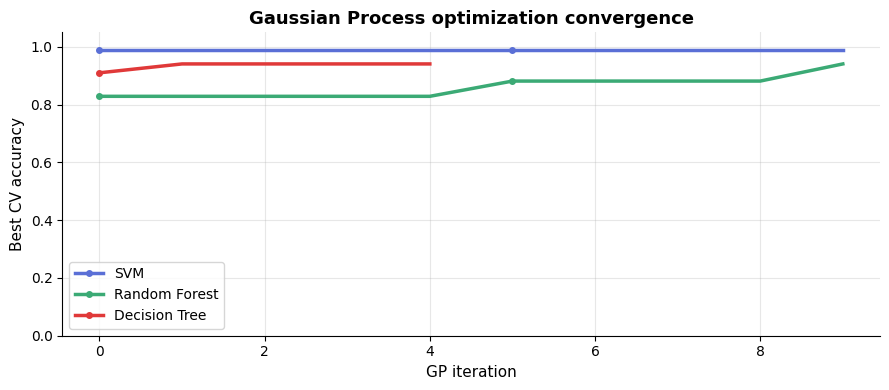

Saved results/gp_convergence.png


In [ ]:
# Plot of GP convergence 
fig, ax = plt.subplots(figsize=(9, 4))

for name, result in [
    ('SVM', svm_gp_result),
    ('Random Forest', rf_gp_result),
    ('Decision Tree', dt_gp_result),
]:
    best_so_far = np.minimum.accumulate(result.func_vals)
    ax.plot(-best_so_far, label=name, color=colors[name],
            lw=2.5, marker='o', markersize=4, markevery=5)

ax.set_xlabel('GP iteration', fontsize=11)
ax.set_ylabel('Best CV accuracy', fontsize=11)
ax.set_title('Gaussian Process optimization convergence', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(f"{outputs}/gp_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {outputs}/gp_convergence.png")

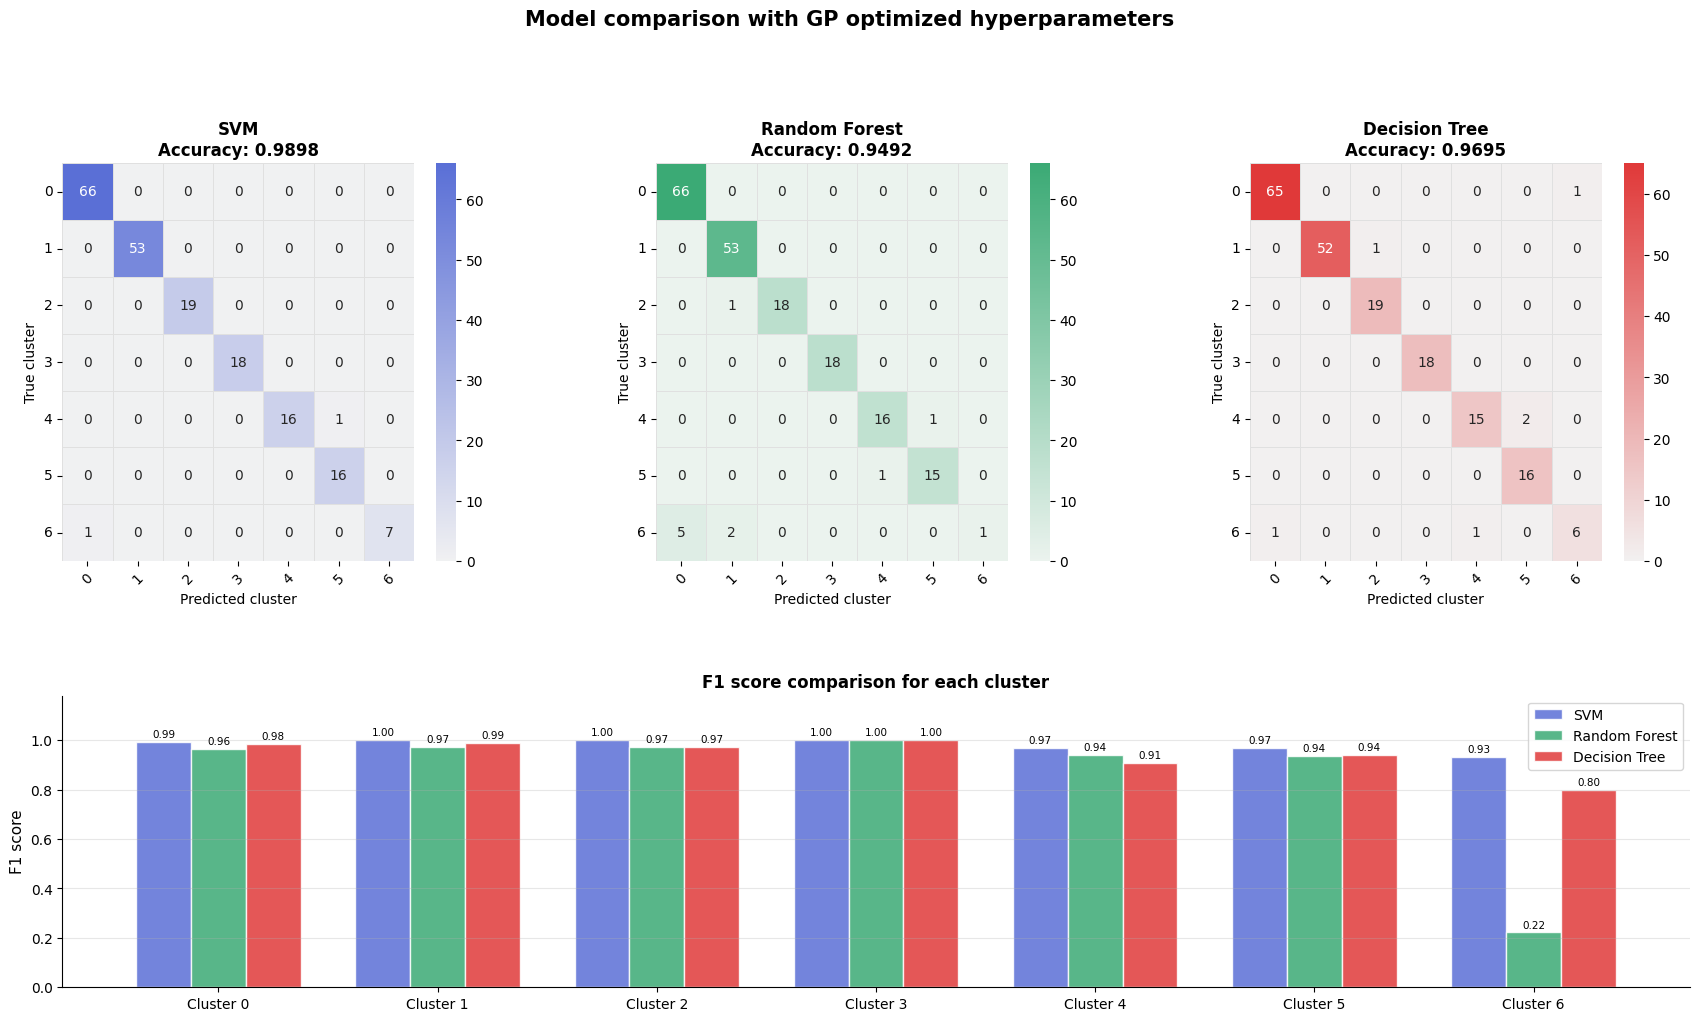

Saved results/model_comparison.png


In [ ]:
# Base learner model comparison
model_results = [
    ('SVM', svm_preds, svm_best_params),
    ('Random Forest', rf_preds, rf_best_params),
    ('Decision Tree', dt_preds, dt_best_params),
]
n_classes  = len(LABEL_NAMES)
n_models   = len(model_results)

fig = plt.figure(figsize=(7 * n_models, 14))
fig.suptitle('Model comparison with GP optimized hyperparameters',
             fontsize=15, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(3, n_models, figure=fig,
                       height_ratios=[3, 2.2, 0.9],
                       hspace=0.5, wspace=0.35)

# Confusion Matrix
for col, (name, preds, _) in enumerate(model_results):
    ax  = fig.add_subplot(gs[0, col])
    cm  = confusion_matrix(y_test, preds, labels=LABEL_NAMES)
    acc = accuracy_score(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(colors[name], as_cmap=True),
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, linecolor='#e0e0e0')
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted cluster', fontsize=10)
    ax.set_ylabel('True cluster', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# F1 bar chart for each cluster
ax_f1 = fig.add_subplot(gs[1, :])
x = np.arange(n_classes)
total_width = 0.75
bar_w = total_width / n_models
offsets = np.linspace(-(total_width - bar_w) / 2, (total_width - bar_w) / 2, n_models)

for offset, (name, preds, _) in zip(offsets, model_results):
    f1s  = f1_score(y_test, preds, average=None, labels=LABEL_NAMES)
    bars = ax_f1.bar(x + offset, f1s, bar_w, label=name,
                     color=colors[name], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax_f1.text(bar.get_x() + bar.get_width() / 2., h + 0.01,
                   f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

ax_f1.set_xticks(x)
ax_f1.set_xticklabels([f'Cluster {l}' for l in LABEL_NAMES], fontsize=10)
ax_f1.set_ylabel('F1 score', fontsize=11)
ax_f1.set_ylim(0, 1.18)
ax_f1.set_title('F1 score comparison for each cluster', fontsize=12, fontweight='bold')
ax_f1.legend(fontsize=10)
ax_f1.grid(axis='y', alpha=0.3)
ax_f1.spines['top'].set_visible(False)
ax_f1.spines['right'].set_visible(False)

fig.savefig(f"{outputs}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {outputs}/model_comparison.png")

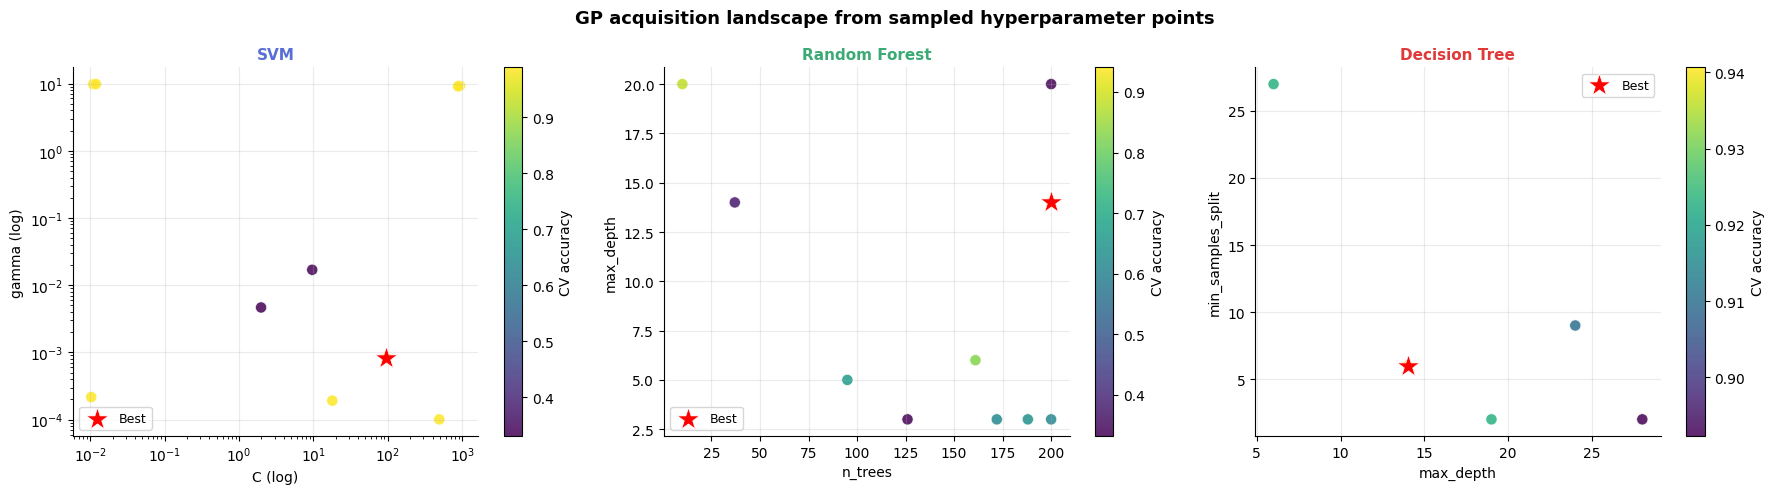

Saved results/acquisition_landscape.png


In [ ]:
# GP acquisition graph
# Shows every sampled point in hyperparameter space, coloured by CV accuracy.
# The two most informative numeric axes are used for each model.

landscape_configs = [
    ('SVM', svm_gp_result, 0, 1, 'C (log)', 'gamma (log)'),
    ('Random Forest', rf_gp_result,  0, 1, 'n_trees', 'max_depth'),
    ('Decision Tree', dt_gp_result,  0, 1, 'max_depth', 'min_samples_split'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GP acquisition landscape from sampled hyperparameter points',
             fontsize=13, fontweight='bold')

for ax, (name, res, xi, yi, xl, yl) in zip(axes, landscape_configs):
    xs   = np.array([p[xi] for p in res.x_iters], dtype=float)
    ys   = np.array([p[yi] for p in res.x_iters], dtype=float)
    accs = -np.array(res.func_vals)

    sc = ax.scatter(xs, ys, c=accs, cmap='viridis', s=65,
                    edgecolors='white', linewidths=0.5, alpha=0.85)
    plt.colorbar(sc, ax=ax, label='CV accuracy')

    ax.scatter([res.x[xi]], [res.x[yi]], marker='*', s=280, c='red',
               zorder=5, label='Best', edgecolors='white', linewidths=0.5)

    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.set_title(name, fontsize=11, fontweight='bold', color=colors[name])
    if name == 'SVM':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(f"{outputs}/acquisition_landscape.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {outputs}/acquisition_landscape.png")